In [1]:
import pandas as pd
df = pd.read_csv(r"C:\ALL\customer_churn_project\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [2]:
# Numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Features:")
print(list(numerical_cols))

print("\nStatistical Summary:")
display(df[numerical_cols].describe())

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Statistical Summary:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [3]:
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes)


tenure              int64
MonthlyCharges    float64
TotalCharges       object
dtype: object


In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(df["TotalCharges"].dtype)

float64


In [ ]:
numerical_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
display(df[numerical_cols].describe())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical Features:")
print(list(categorical_cols))

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].unique())

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

customerID
Unique values: 7043
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
Unique values: 2
['Female' 'Male']

Partner
Unique values: 2
['Yes' 'No']

Dependents
Unique values: 2
['No' 'Yes']

PhoneService
Unique values: 2
['No' 'Yes']

MultipleLines
Unique values: 3
['No phone service' 'No' 'Yes']

InternetService
Unique values: 3
['DSL' 'Fiber optic' 'No']

OnlineSecurity
Unique values: 3
['No' 'Yes' 'No internet service']

OnlineBackup
Unique values: 3
['Yes' 'No' 'No internet service']

DeviceProtection
Unique values: 3
['No' 'Yes' 'No internet service']

TechSupport
Unique values: 3
['No' 'Yes' 'No internet service']

StreamingTV
Unique values: 3
['No' 

In [7]:
df["customerID"].nunique()

7043

Churn
No     5174
Yes    1869
Name: count, dtype: int64


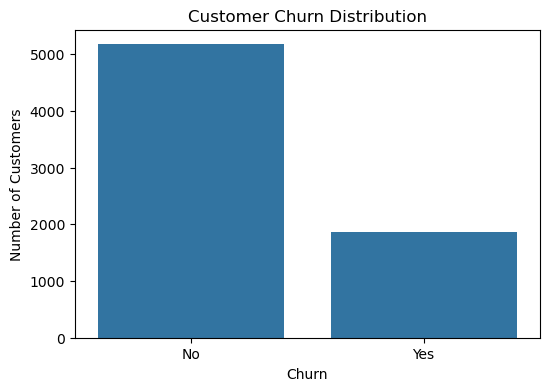

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

churn_counts = df["Churn"].value_counts()

print(churn_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [9]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage.round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [10]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


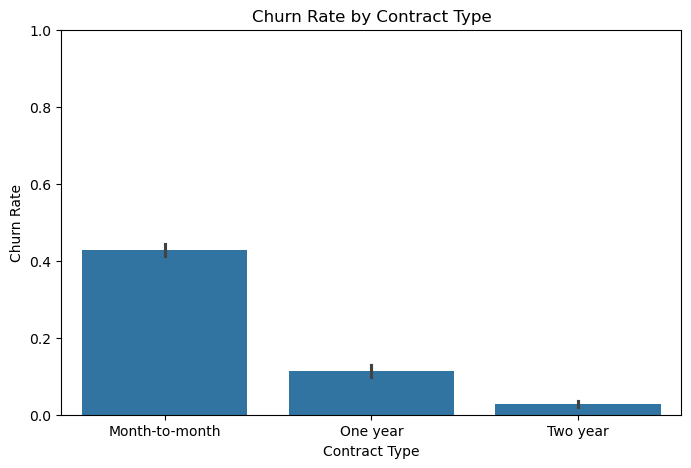

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Contract",
    y=df["Churn"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)

plt.show()

In [12]:
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(contract_churn_rate.round(2))

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


In [13]:
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(contract_churn_rate.round(2))

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


In [14]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [15]:
tenure_churn_rate = (
    df.groupby("TenureGroup", observed=False)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(tenure_churn_rate.round(2))

TenureGroup
0-6 months      52.94
7-12 months     35.89
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51
Name: Churn, dtype: float64


In [16]:
monthly_churn = (
    df.groupby("Churn")["MonthlyCharges"]
      .agg(["mean", "median", "min", "max"])
)

display(monthly_churn.round(2))

,mean,median,min,max
Churn,,,,
No,61.27,64.43,18.25,118.75
Yes,74.44,79.65,18.85,118.35


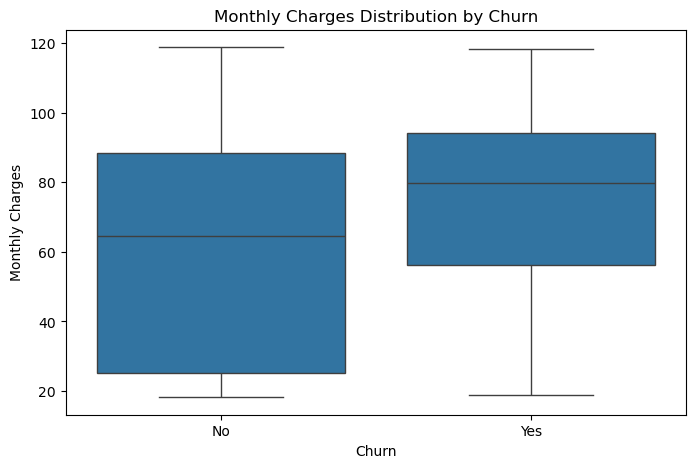

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [18]:
monthly_churn = (
    df.groupby("Churn")["MonthlyCharges"]
      .agg(["mean", "median", "min", "max"])
)

display(monthly_churn.round(2))

,mean,median,min,max
Churn,,,,
No,61.27,64.43,18.25,118.75
Yes,74.44,79.65,18.85,118.35


In [19]:
df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 60, 80, 100, 120],
    labels=[
        "<=40",
        "41-60",
        "61-80",
        "81-100",
        "101-120"
    ]
)

charge_churn = (
    df.groupby("MonthlyChargeGroup", observed=False)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(charge_churn.round(2))

MonthlyChargeGroup
<=40       11.64
41-60      25.56
61-80      32.42
81-100     37.02
101-120    28.05
Name: Churn, dtype: float64


In [20]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(internet_churn.round(2))

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


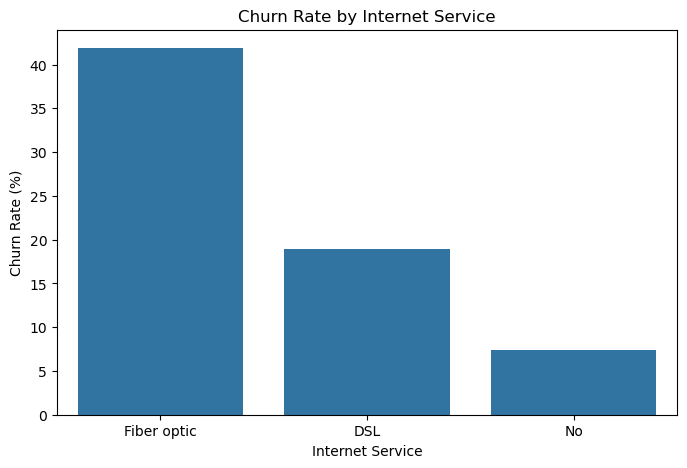

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

In [22]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(internet_churn.round(2))

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


In [23]:
support_churn = (
    df.groupby("TechSupport")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(support_churn.round(2))

TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64


In [24]:
gender_churn = (
    df.groupby("gender")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(gender_churn.round(2))

gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64


In [25]:
dependents_churn = (
    df.groupby("Dependents")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(dependents_churn.round(2))

Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64


In [26]:
partner_churn = (
    df.groupby("Partner")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(partner_churn.round(2))

Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64


In [27]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(payment_churn.round(2))


PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64


In [28]:
skip_columns = [
    "customerID",
    "gender",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

print("EDA me skip karne wale columns:")
for col in skip_columns:
    print("-", col)

EDA me skip karne wale columns:
- customerID
- gender
- PhoneService
- MultipleLines
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- StreamingTV
- StreamingMovies
- PaperlessBilling


In [29]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [30]:
print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

TotalCharges dtype: float64
Missing TotalCharges: 0


In [31]:
print(df.dtypes)


customerID              object
gender                  object
SeniorCitizen            int64
Partner                 object
Dependents              object
tenure                   int64
PhoneService            object
MultipleLines           object
InternetService         object
OnlineSecurity          object
OnlineBackup            object
DeviceProtection        object
TechSupport             object
StreamingTV             object
StreamingMovies         object
Contract                object
PaperlessBilling        object
PaymentMethod           object
MonthlyCharges         float64
TotalCharges           float64
Churn                   object
TenureGroup           category
MonthlyChargeGroup    category
dtype: object


In [32]:
df = df.drop(columns=["TenureGroup", "MonthlyChargeGroup"])


In [33]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [35]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df.groupby("Churn")[num_cols].agg(
    ["mean", "median", "min", "max"]
)

tenure                MonthlyCharges                         \
            mean median min max           mean  median    min     max   
Churn                                                                   
No     37.569965   38.0   0  72      61.265124  64.425  18.25  118.75   
Yes    17.979133   10.0   1  72      74.441332  79.650  18.85  118.35   

      TotalCharges                            
              mean    median    min      max  
Churn                                         
No     2549.911442  1679.525   0.00  8672.45  
Yes    1531.796094   703.550  18.85  8684.80

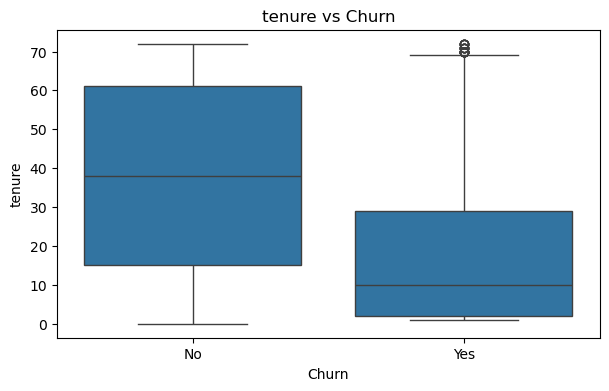

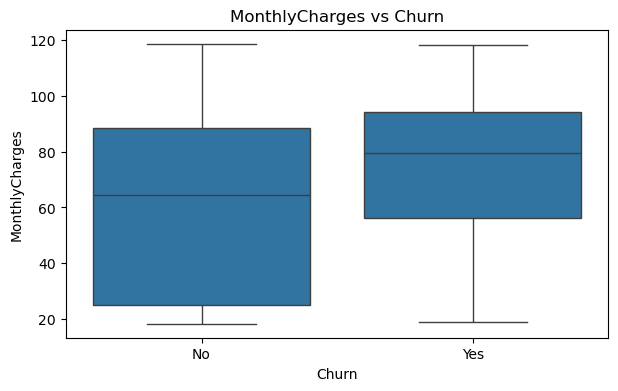

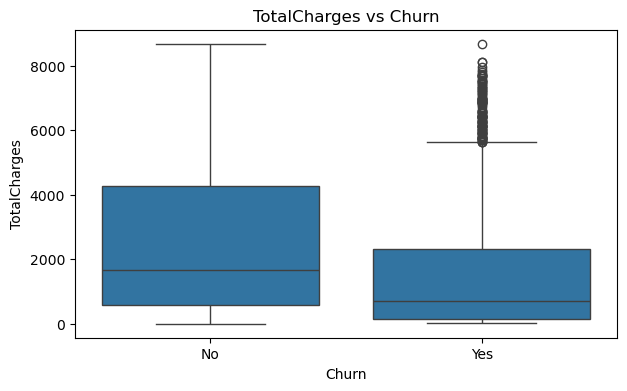

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} vs Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

In [37]:
categorical_cols = [
    "Partner",
    "Dependents",
    "InternetService",
    "TechSupport",
    "Contract",
    "PaymentMethod"
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"{col} vs Churn")
    print(f"{'='*50}")
    
    churn_rate = (
        df.groupby(col, observed=True)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )
    
    print(churn_rate.round(2))


Partner vs Churn
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

Dependents vs Churn
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64

InternetService vs Churn
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

TechSupport vs Churn
TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64

Contract vs Churn
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

PaymentMethod vs Churn
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64


In [38]:
# =====================================================
# SELECTED FEATURES FOR MODELING
# =====================================================

selected_features = [
    "SeniorCitizen",
    "Dependents",
    "tenure",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "Contract",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges"
]

model_df = df[
    selected_features + ["Churn"]
].copy()

print("Selected dataset shape:", model_df.shape)

print("\nSelected features:")
print(model_df.columns.tolist())

Selected dataset shape: (7043, 11)

Selected features:
['SeniorCitizen', 'Dependents', 'tenure', 'InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [39]:
# =====================================================
# SAVE PROCESSED DATASET
# =====================================================

import os

os.makedirs("../data/processed", exist_ok=True)

model_df.to_csv(
    "../data/processed/churn_model_data.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [40]:
# =====================================================
# 1. LOAD PROCESSED DATASET
# =====================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split


# Load processed dataset
df_model = pd.read_csv(
    "../data/processed/churn_model_data.csv"
)


# Check shape
print("Dataset shape:", df_model.shape)


# Check columns
print("\nColumns:")
print(df_model.columns.tolist())


# Check missing values
print("\nMissing values:")
print(df_model.isnull().sum())


# =====================================================
# 2. FEATURES AND TARGET
# =====================================================

X = df_model.drop(
    columns=["Churn"]
)

y = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})


print("\nX shape:", X.shape)
print("y shape:", y.shape)


# =====================================================
# 3. TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)


# =====================================================
# 4. TARGET DISTRIBUTION
# =====================================================

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining target proportion:")
print(y_train.value_counts(normalize=True))

print("\nTesting target proportion:")
print(y_test.value_counts(normalize=True))

Dataset shape: (7043, 11)

Columns:
['SeniorCitizen', 'Dependents', 'tenure', 'InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing values:
SeniorCitizen      0
Dependents         0
tenure             0
InternetService    0
OnlineSecurity     0
TechSupport        0
Contract           0
PaymentMethod      0
MonthlyCharges     0
TotalCharges       0
Churn              0
dtype: int64

X shape: (7043, 10)
y shape: (7043,)

Training shape: (5634, 10)
Testing shape: (1409, 10)

Training target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64

Training target proportion:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing target proportion:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [41]:
# =====================================================
# 2. PREPROCESSING PIPELINE
# =====================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# =====================================================
# NUMERICAL FEATURES
# =====================================================

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]


# =====================================================
# CATEGORICAL FEATURES
# =====================================================

categorical_features = [
    "Dependents",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "Contract",
    "PaymentMethod"
]


# =====================================================
# NUMERICAL PIPELINE
# =====================================================

numeric_transformer = Pipeline([
    (
        "scaler",
        StandardScaler()
    )
])


# =====================================================
# CATEGORICAL PIPELINE
# =====================================================

categorical_transformer = Pipeline([
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


# =====================================================
# COMBINED PREPROCESSOR
# =====================================================

preprocessor = ColumnTransformer([

    (
        "num",
        numeric_transformer,
        numeric_features
    ),

    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])


print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [42]:
# =====================================================
# 3. MODEL TRAINING & COMPARISON
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# =====================================================
# 1. DEFINE MODELS
# =====================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}


# =====================================================
# 2. TRAIN & EVALUATE
# =====================================================

results = []


for name, model in models.items():

    print(f"\nTraining {name}...")

    pipeline = Pipeline([

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            model
        )
    ])


    # Train
    pipeline.fit(
        X_train,
        y_train
    )


    # Predictions
    y_pred = pipeline.predict(
        X_test
    )

    y_prob = pipeline.predict_proba(
        X_test
    )[:, 1]


    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )


    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "ROC-AUC": roc_auc
    })


    print(
        f"Accuracy: {accuracy:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f} | "
        f"ROC-AUC: {roc_auc:.4f}"
    )


# =====================================================
# 3. RESULTS TABLE
# =====================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)


print("\n========================================")
print("MODEL COMPARISON")
print("========================================")

display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1": "{:.2%}",
        "ROC-AUC": "{:.2%}"
    })
)


Training Logistic Regression...
Accuracy: 0.7949 | Precision: 0.6332 | Recall: 0.5401 | F1: 0.5830 | ROC-AUC: 0.8394

Training Decision Tree...
Accuracy: 0.7984 | Precision: 0.6347 | Recall: 0.5668 | F1: 0.5989 | ROC-AUC: 0.8293

Training Random Forest...
Accuracy: 0.7580 | Precision: 0.5328 | Recall: 0.7166 | F1: 0.6112 | ROC-AUC: 0.8369

Training XGBoost...
Accuracy: 0.8013 | Precision: 0.6546 | Recall: 0.5321 | F1: 0.5870 | ROC-AUC: 0.8401

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,75.80%,53.28%,71.66%,61.12%,83.69%
1,Decision Tree,79.84%,63.47%,56.68%,59.89%,82.93%
2,XGBoost,80.13%,65.46%,53.21%,58.70%,84.01%
3,Logistic Regression,79.49%,63.32%,54.01%,58.30%,83.94%


In [43]:
# =====================================================
# 4. STRATIFIED 5-FOLD CROSS-VALIDATION
# =====================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })


# Results dataframe
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)


print("========================================")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("========================================")

display(
    cv_results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1": "{:.2%}",
        "ROC-AUC": "{:.2%}"
    })
)

5-FOLD CROSS-VALIDATION RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,77.23%,55.35%,73.78%,63.20%,84.03%
1,Logistic Regression,79.82%,64.49%,53.38%,58.38%,84.29%
2,XGBoost,80.19%,66.16%,52.24%,58.31%,84.22%
3,Decision Tree,79.18%,63.54%,51.30%,56.53%,82.98%


In [44]:
# =====================================================
# 5. RANDOM FOREST HYPERPARAMETER TUNING
# =====================================================

from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])


# Hyperparameter search space
param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [8, 10, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}


grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)


print("Starting Random Forest Grid Search...")

grid_search.fit(
    X_train,
    y_train
)


print("\n========================================")
print("BEST PARAMETERS")
print("========================================")

print(grid_search.best_params_)


print("\n========================================")
print("BEST CROSS-VALIDATION F1 SCORE")
print("========================================")

print(
    f"{grid_search.best_score_:.4f}"
)

Starting Random Forest Grid Search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

BEST PARAMETERS
{'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}

BEST CROSS-VALIDATION F1 SCORE
0.6349


In [45]:
# =====================================================
# 6. FINAL MODEL TEST EVALUATION
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Best tuned pipeline
best_model = grid_search.best_estimator_


# Predictions
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]


# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)


print("========================================")
print("FINAL MODEL TEST RESULTS")
print("========================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n========================================")
print("CONFUSION MATRIX")
print("========================================")

print(cm)


# Classification Report
print("\n========================================")
print("CLASSIFICATION REPORT")
print("========================================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

FINAL MODEL TEST RESULTS
Accuracy : 0.7551
Precision: 0.5270
Recall   : 0.7567
F1 Score : 0.6213
ROC-AUC  : 0.8403

CONFUSION MATRIX
[[781 254]
 [ 91 283]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



### shap (this show why custumern churn )

In [46]:
# =====================================================
# 7B. SHAP EXPLAINABILITY
# =====================================================

import shap
import numpy as np
import pandas as pd

# Best model pipeline se components nikalo
preprocessor_fitted = best_model.named_steps["preprocessor"]
rf_model = best_model.named_steps["model"]


# -----------------------------------------------------
# 1. Transform test data
# -----------------------------------------------------

X_test_transformed = preprocessor_fitted.transform(X_test)

print("Transformed shape:", X_test_transformed.shape)


# -----------------------------------------------------
# 2. Get feature names
# -----------------------------------------------------

feature_names = preprocessor_fitted.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 20 features:")
print(feature_names[:20])


# -----------------------------------------------------
# 3. Create SHAP Tree Explainer
# -----------------------------------------------------

explainer = shap.TreeExplainer(
    rf_model
)


# -----------------------------------------------------
# 4. Calculate SHAP values
# -----------------------------------------------------

shap_values = explainer.shap_values(
    X_test_transformed
)


print("\nSHAP values type:", type(shap_values))

if isinstance(shap_values, list):
    print("SHAP values shapes:")
    for i, value in enumerate(shap_values):
        print(f"Class {i}:", value.shape)

else:
    print("SHAP values shape:", shap_values.shape)

Transformed shape: (1409, 22)
Number of features: 22

First 20 features:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__Dependents_No' 'cat__Dependents_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__TechSupport_No' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__Contract_Month-to-month'
 'cat__Contract_One year' 'cat__Contract_Two year'
 'cat__PaymentMethod_Bank transfer (automatic)'
 'cat__PaymentMethod_Credit card (automatic)']

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1409, 22, 2)


In [47]:
# =====================================================
# 7C. GLOBAL SHAP FEATURE IMPORTANCE
# =====================================================

# Class 1 = Churn
shap_class_1 = shap_values[:, :, 1]

# Mean absolute SHAP value
mean_abs_shap = np.abs(shap_class_1).mean(axis=0)

# Create importance dataframe
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

# Sort descending
shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)


print("========================================")
print("TOP SHAP FEATURES")
print("========================================")

display(
    shap_importance.head(15)
)

TOP SHAP FEATURES


,Feature,Mean_Absolute_SHAP
0,cat__Contract_Month-to-month,0.086412
1,num__tenure,0.056726
2,cat__InternetService_Fiber optic,0.047269
3,cat__OnlineSecurity_No,0.039831
4,cat__Contract_Two year,0.037003
5,cat__TechSupport_No,0.035916
6,num__TotalCharges,0.029254
7,cat__PaymentMethod_Electronic check,0.028035
8,num__MonthlyCharges,0.026763
9,cat__InternetService_DSL,0.015266


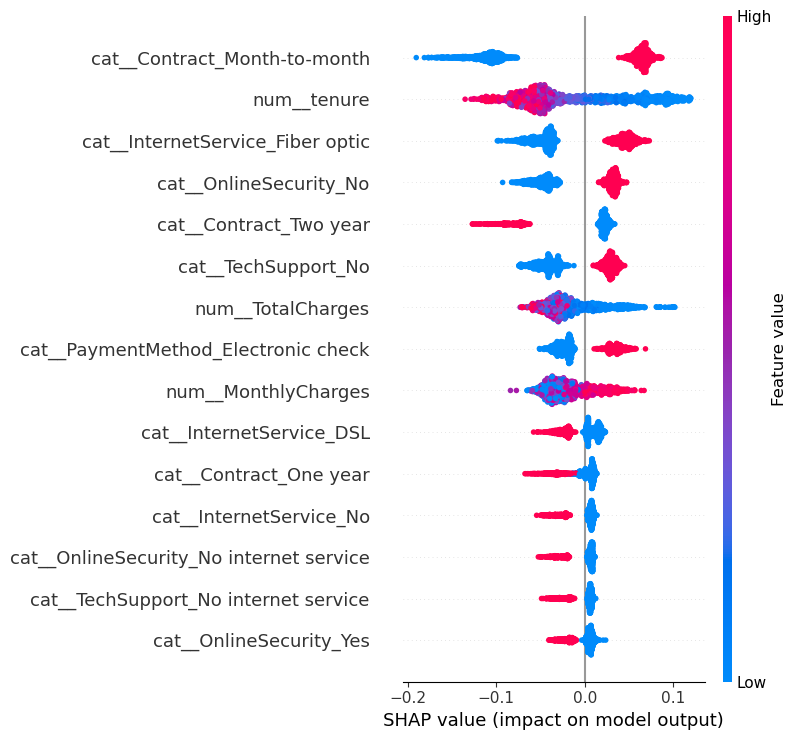

In [48]:
# =====================================================
# 7D. SHAP SUMMARY PLOT
# =====================================================

shap.summary_plot(
    shap_class_1,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

In [49]:
# =====================================================
# 7E. INDIVIDUAL CUSTOMER SHAP EXPLANATION
# =====================================================

# Customer index
customer_index = 0

# SHAP values for selected customer
customer_shap = shap_class_1[customer_index]

# Original transformed customer values
customer_values = X_test_transformed[customer_index]

# Convert sparse row if required
if hasattr(customer_values, "toarray"):
    customer_values = customer_values.toarray().flatten()
else:
    customer_values = np.asarray(customer_values).flatten()


# Create explanation dataframe
customer_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": customer_shap,
    "Feature_Value": customer_values
})


# Sort by absolute SHAP impact
customer_explanation["Absolute_SHAP"] = (
    customer_explanation["SHAP_Value"].abs()
)

customer_explanation = customer_explanation.sort_values(
    by="Absolute_SHAP",
    ascending=False
).reset_index(drop=True)


print("========================================")
print("INDIVIDUAL CUSTOMER SHAP EXPLANATION")
print("========================================")

display(
    customer_explanation.head(10)
)

INDIVIDUAL CUSTOMER SHAP EXPLANATION


,Feature,SHAP_Value,Feature_Value,Absolute_SHAP
0,cat__Contract_Month-to-month,-0.118204,0.000000,0.118204
1,num__tenure,-0.099751,1.608483,0.099751
2,cat__Contract_Two year,-0.098103,1.000000,0.098103
3,num__TotalCharges,-0.048562,2.706828,0.048562
4,cat__OnlineSecurity_No,-0.037867,0.000000,0.037867
5,cat__TechSupport_No,-0.030293,0.000000,0.030293
6,cat__InternetService_Fiber optic,0.026497,1.000000,0.026497
7,cat__OnlineSecurity_Yes,-0.017281,1.000000,0.017281
8,cat__PaymentMethod_Electronic check,-0.016482,0.000000,0.016482
9,cat__Dependents_No,-0.014118,0.000000,0.014118


In [50]:
# =====================================================
# 7F. CLEAN BUSINESS-FRIENDLY SHAP EXPLANATION
# =====================================================

def clean_shap_feature(feature):

    feature = feature.replace("num__", "")
    feature = feature.replace("cat__", "")

    mapping = {
        "SeniorCitizen": "Senior Citizen",
        "tenure": "Customer Tenure",
        "MonthlyCharges": "Monthly Charges",
        "TotalCharges": "Total Charges",

        "Dependents_No": "No Dependents",
        "Dependents_Yes": "Has Dependents",

        "InternetService_DSL": "DSL Internet",
        "InternetService_Fiber optic": "Fiber Optic Internet",
        "InternetService_No": "No Internet Service",

        "OnlineSecurity_No": "No Online Security",
        "OnlineSecurity_No internet service": "No Internet Service",
        "OnlineSecurity_Yes": "Has Online Security",

        "TechSupport_No": "No Tech Support",
        "TechSupport_No internet service": "No Internet Service",
        "TechSupport_Yes": "Has Tech Support",

        "Contract_Month-to-month": "Month-to-Month Contract",
        "Contract_One year": "One-Year Contract",
        "Contract_Two year": "Two-Year Contract",

        "PaymentMethod_Bank transfer (automatic)": "Bank Transfer",
        "PaymentMethod_Credit card (automatic)": "Credit Card",
        "PaymentMethod_Electronic check": "Electronic Check",
        "PaymentMethod_Mailed check": "Mailed Check"
    }

    return mapping.get(feature, feature)


# Copy explanation
clean_explanation = customer_explanation.copy()


# Clean feature names
clean_explanation["Feature"] = (
    clean_explanation["Feature"]
    .apply(clean_shap_feature)
)


# Keep only meaningful active categorical features
meaningful_rows = []

for _, row in clean_explanation.iterrows():

    feature = row["Feature"]
    value = row["Feature_Value"]

    # Numerical features
    if feature in [
        "Senior Citizen",
        "Customer Tenure",
        "Monthly Charges",
        "Total Charges"
    ]:
        meaningful_rows.append(row)

    # Active one-hot features
    elif value > 0.5:
        meaningful_rows.append(row)


clean_explanation = pd.DataFrame(
    meaningful_rows
)


# Sort by impact
clean_explanation["Absolute_SHAP"] = (
    clean_explanation["SHAP_Value"].abs()
)

clean_explanation = clean_explanation.sort_values(
    by="Absolute_SHAP",
    ascending=False
).reset_index(drop=True)


print("========================================")
print("BUSINESS-FRIENDLY SHAP EXPLANATION")
print("========================================")

display(
    clean_explanation[
        [
            "Feature",
            "SHAP_Value",
            "Feature_Value"
        ]
    ].head(10)
)

BUSINESS-FRIENDLY SHAP EXPLANATION


,Feature,SHAP_Value,Feature_Value
0,Customer Tenure,-0.099751,1.608483
1,Two-Year Contract,-0.098103,1.000000
2,Total Charges,-0.048562,2.706828
3,Fiber Optic Internet,0.026497,1.000000
4,Has Online Security,-0.017281,1.000000
5,Has Dependents,-0.012616,1.000000
6,Credit Card,-0.011372,1.000000
7,Has Tech Support,-0.011047,1.000000
8,Senior Citizen,-0.001795,-0.441773
9,Monthly Charges,0.000013,1.629976


In [51]:
# =====================================================
# 8. SAVE FINAL MODEL
# =====================================================

import os
import joblib

# Models directory
os.makedirs("../models", exist_ok=True)

# Save complete pipeline
model_path = "../models/churn_model1.pkl"

joblib.dump(
    best_model,
    model_path
)

print("========================================")
print("MODEL SAVED SUCCESSFULLY")
print("========================================")

print("Path:", model_path)

MODEL SAVED SUCCESSFULLY
Path: ../models/churn_model1.pkl


In [52]:
# =====================================================
# VERIFY SAVED MODEL
# =====================================================

loaded_model = joblib.load(
    "../models/churn_model1.pkl"
)

print("Model loaded successfully!")

print("\nModel type:")
print(type(loaded_model))

print("\nPipeline steps:")
print(loaded_model.named_steps)

Model loaded successfully!

Model type:
<class 'sklearn.pipeline.Pipeline'>

Pipeline steps:
{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Dependents', 'InternetService',
                                  'OnlineSecurity', 'TechSupport', 'Contract',
                                  'PaymentMethod'])]), 'model': RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)}
